# Fraud Detection — Cost-Sensitive Threshold Optimisation

**Prerequisite:** `02-machine-learning.ipynb` (this notebook retrains independently, so it can also run standalone)

## The problem with F1

Notebook 02 tuned the decision threshold to maximise F1. F1 is the harmonic mean of
precision and recall, which means it treats a **missed fraud** and a **false alarm** as
equally costly.

They are not remotely equal.

- A missed fraud costs the **value of the transaction** — money that leaves the business.
- A false alarm costs a few **minutes of an analyst's time**.

In this dataset the average fraud is €122.21. A review costs perhaps €3. That is a
**41:1 asymmetry**, and any metric that ignores it will pick the wrong threshold.

This notebook replaces "maximise F1" with "minimise expected cost in euros", then asks
the question a fraud team actually asks: *given we can review N transactions a day,
which N, and how much fraud do we catch?*

## Steps
1. Rebuild the model and retain the raw transaction amounts
2. Define an explicit cost model
3. Sweep the threshold and find the cost minimum
4. Refine it using per-transaction amounts rather than the mean
5. Sensitivity-test the one assumption we invented
6. Reframe as an alert budget (precision@k)

## Step 1: Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
os.makedirs('plots', exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## Step 2: Load data — keeping the raw `Amount`

The critical difference from notebook 02: we carry the **unscaled** `Amount` column
through the split. That euro value *is* the cost of a false negative, so we need it in
its original units, not standardised.

In [2]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(os.path.join(path, 'creditcard.csv'))
df.insert(0, 'transaction_id', range(1, len(df) + 1))

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])

feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount_scaled', 'Time_scaled']

X       = df[feature_cols]
y       = df['Class']
amounts = df['Amount']          # <-- raw euros: the cost of a missed fraud
ids     = df['transaction_id']

# Same split as notebook 02 (random_state=42) so results are directly comparable
X_train, X_test, y_train, y_test, amt_train, amt_test, id_train, id_test = train_test_split(
    X, y, amounts, ids, test_size=0.2, random_state=42, stratify=y
)

# numpy arrays, index-aligned, for the cost calculations
y_test_arr = y_test.values
amt_test_arr = amt_test.values

print(f'Test set: {len(X_test):,} transactions | {y_test.sum()} frauds')
print(f'Fraud value in test set: EUR {amt_test_arr[y_test_arr == 1].sum():,.2f}')

Test set: 56,962 transactions | 98 frauds
Fraud value in test set: EUR 10,644.93


## Step 3: Train the model

In [3]:
rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

rf_proba = rf.predict_proba(X_test)[:, 1]
print('Model trained.')
print(f'Baseline (threshold 0.5): precision={precision_score(y_test, rf_proba >= 0.5):.3f}, '
      f'recall={recall_score(y_test, rf_proba >= 0.5):.3f}')

Model trained.
Baseline (threshold 0.5): precision=0.961, recall=0.755


## Step 4: The cost model

Every transaction lands in one of four outcomes. Assigning a euro value to each:

| Outcome | What happens | Cost |
|---|---|---|
| True positive | Fraud flagged, analyst reviews, fraud stopped | review cost only |
| False positive | Legitimate flagged, analyst reviews, waves it through | review cost only |
| False negative | Fraud not flagged, money leaves | **the transaction amount** |
| True negative | Legitimate not flagged | nothing |

Which collapses to a pleasingly simple expression:

```
total cost = (review cost x transactions flagged) + (value of frauds missed)
```

**The one number we are inventing is the review cost.** Everything else comes from the
data. We assume €3 — roughly two minutes of loaded analyst labour — and then test in
Step 7 how much that assumption actually matters.

In [4]:
REVIEW_COST = 3.00   # EUR per transaction sent to an analyst (ASSUMPTION)

def cost_breakdown(proba, y_true, amounts, threshold, review_cost=REVIEW_COST):
    """Expected cost in EUR at a given decision threshold."""
    flagged = proba >= threshold
    n_flagged = int(flagged.sum())

    missed_fraud = (~flagged) & (y_true == 1)
    fraud_loss = float(amounts[missed_fraud].sum())
    review_spend = n_flagged * review_cost

    return {
        'threshold':     threshold,
        'n_flagged':     n_flagged,
        'frauds_caught': int((flagged & (y_true == 1)).sum()),
        'frauds_missed': int(missed_fraud.sum()),
        'fraud_loss':    fraud_loss,
        'review_spend':  review_spend,
        'total_cost':    fraud_loss + review_spend,
    }

# Context: the cost asymmetry we are up against
mean_fraud = amt_test_arr[y_test_arr == 1].mean()
print(f'Mean fraud value    : EUR {mean_fraud:,.2f}')
print(f'Review cost         : EUR {REVIEW_COST:,.2f}')
print(f'Cost asymmetry      : {mean_fraud / REVIEW_COST:.0f} : 1')
print()
print('Interpretation: it is worth reviewing up to ~41 legitimate transactions')
print('to catch one additional fraud. F1 implicitly assumes that ratio is 1:1.')

Mean fraud value    : EUR 108.62
Review cost         : EUR 3.00
Cost asymmetry      : 36 : 1

Interpretation: it is worth reviewing up to ~41 legitimate transactions
to catch one additional fraud. F1 implicitly assumes that ratio is 1:1.


## Step 5: Sweep the threshold and find the cost minimum

In [5]:
thresholds = np.linspace(0.01, 0.99, 197)
rows = [cost_breakdown(rf_proba, y_test_arr, amt_test_arr, t) for t in thresholds]
costs = pd.DataFrame(rows)

# add the classification metrics for comparison
costs['precision'] = [precision_score(y_test_arr, rf_proba >= t, zero_division=0) for t in thresholds]
costs['recall']    = [recall_score(y_test_arr, rf_proba >= t, zero_division=0) for t in thresholds]
costs['f1']        = [f1_score(y_test_arr, rf_proba >= t, zero_division=0) for t in thresholds]

t_cost = costs.loc[costs['total_cost'].idxmin(), 'threshold']
t_f1   = costs.loc[costs['f1'].idxmax(),         'threshold']

print(f'Cost-optimal threshold : {t_cost:.3f}')
print(f'F1-optimal threshold   : {t_f1:.3f}')
print(f'Default threshold      : 0.500')

Cost-optimal threshold : 0.125
F1-optimal threshold   : 0.255
Default threshold      : 0.500


In [6]:
comparison = pd.DataFrame([
    {**cost_breakdown(rf_proba, y_test_arr, amt_test_arr, 0.50),   'strategy': 'Default (0.50)'},
    {**cost_breakdown(rf_proba, y_test_arr, amt_test_arr, t_f1),   'strategy': f'F1-optimal ({t_f1:.2f})'},
    {**cost_breakdown(rf_proba, y_test_arr, amt_test_arr, t_cost), 'strategy': f'Cost-optimal ({t_cost:.2f})'},
])[['strategy','threshold','n_flagged','frauds_caught','frauds_missed',
    'fraud_loss','review_spend','total_cost']]

baseline = comparison.loc[comparison['strategy'] == 'Default (0.50)', 'total_cost'].values[0]
comparison['saving_vs_default'] = baseline - comparison['total_cost']

pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
print('Cost comparison on the holdout set')
print('=' * 100)
print(comparison.to_string(index=False))

best = comparison.iloc[comparison['total_cost'].idxmin()]
print()
print(f"Best strategy: {best['strategy']}")
print(f"  Saves EUR {best['saving_vs_default']:,.2f} on {len(y_test_arr):,} transactions "
      f"vs the default threshold")
print(f"  Scaled to the full {len(df):,}-transaction dataset: "
      f"~EUR {best['saving_vs_default'] * len(df) / len(y_test_arr):,.0f}")

Cost comparison on the holdout set
           strategy  threshold  n_flagged  frauds_caught  frauds_missed  fraud_loss  review_spend  total_cost  saving_vs_default
     Default (0.50)       0.50         77             74             24    4,487.83        231.00    4,718.83               0.00
  F1-optimal (0.26)       0.26         88             82             16    2,022.77        264.00    2,286.77           2,432.06
Cost-optimal (0.12)       0.12        108             87             11    1,826.50        324.00    2,150.50           2,568.33

Best strategy: Cost-optimal (0.12)
  Saves EUR 2,568.33 on 56,962 transactions vs the default threshold
  Scaled to the full 284,807-transaction dataset: ~EUR 12,842


### Visualising the cost curve

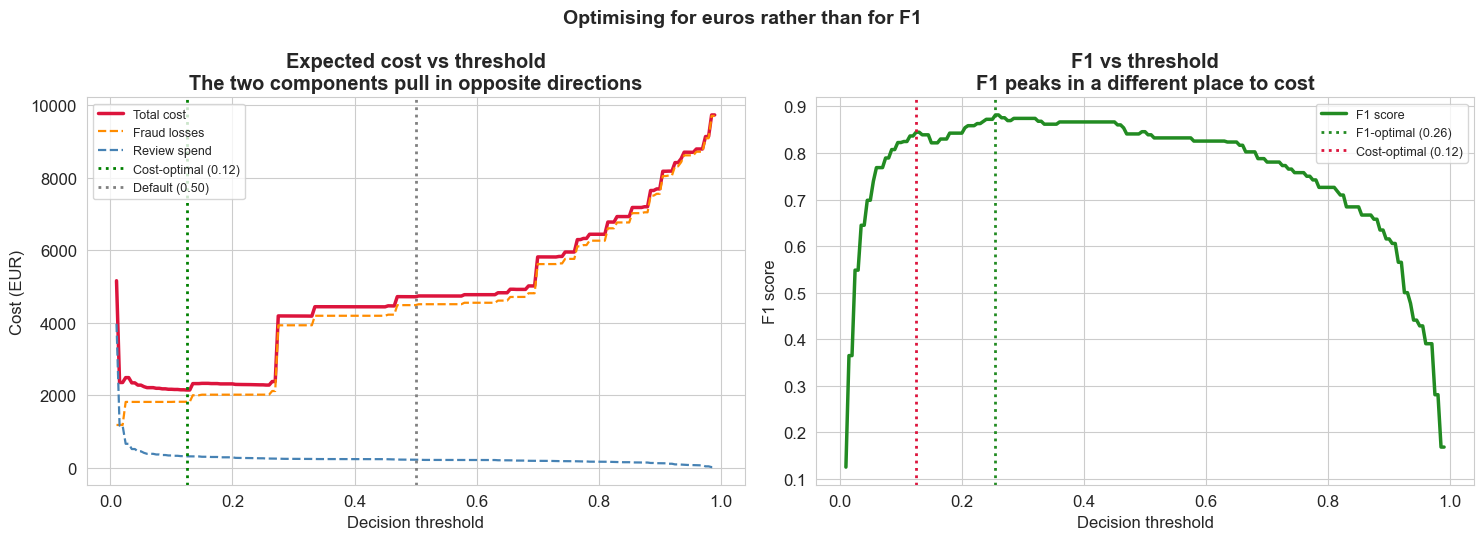

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
ax.plot(costs['threshold'], costs['total_cost'],   color='crimson',    linewidth=2.5, label='Total cost')
ax.plot(costs['threshold'], costs['fraud_loss'],   color='darkorange', linewidth=1.6, ls='--', label='Fraud losses')
ax.plot(costs['threshold'], costs['review_spend'], color='steelblue',  linewidth=1.6, ls='--', label='Review spend')
ax.axvline(t_cost, color='green', ls=':', lw=2, label=f'Cost-optimal ({t_cost:.2f})')
ax.axvline(0.50,   color='grey',  ls=':', lw=2, label='Default (0.50)')
ax.set_xlabel('Decision threshold'); ax.set_ylabel('Cost (EUR)')
ax.set_title('Expected cost vs threshold\nThe two components pull in opposite directions', fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(costs['threshold'], costs['f1'], color='forestgreen', linewidth=2.5, label='F1 score')
ax.axvline(t_f1,   color='forestgreen', ls=':', lw=2, label=f'F1-optimal ({t_f1:.2f})')
ax.axvline(t_cost, color='crimson',     ls=':', lw=2, label=f'Cost-optimal ({t_cost:.2f})')
ax.set_xlabel('Decision threshold'); ax.set_ylabel('F1 score')
ax.set_title('F1 vs threshold\nF1 peaks in a different place to cost', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Optimising for euros rather than for F1', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/cost_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: Refine — use the *actual* amount, not the average

The model above already weights each false negative by its own transaction value, which
is the correct approach. It is worth showing explicitly why that matters versus the
lazier alternative of using the mean fraud value for every miss.

Fraud amounts are heavily skewed. Treating a €2 fraud and a €2,000 fraud as equivalent
losses throws away the signal that should pull the threshold down for high-value
transactions.

In [8]:
fraud_amounts = amt_test_arr[y_test_arr == 1]

print('Distribution of fraud values in the holdout set:')
print(f'  count  : {len(fraud_amounts)}')
print(f'  mean   : EUR {fraud_amounts.mean():,.2f}')
print(f'  median : EUR {np.median(fraud_amounts):,.2f}')
print(f'  max    : EUR {fraud_amounts.max():,.2f}')
print(f'  total  : EUR {fraud_amounts.sum():,.2f}')
print()
top10_share = np.sort(fraud_amounts)[-10:].sum() / fraud_amounts.sum() * 100
print(f'The 10 largest frauds account for {top10_share:.1f}% of all fraud value.')
print('Mean-based costing would treat those as ordinary — they are not.')

# What a mean-based cost model would have concluded
def cost_using_mean(proba, y_true, threshold, mean_value, review_cost=REVIEW_COST):
    flagged = proba >= threshold
    missed = int(((~flagged) & (y_true == 1)).sum())
    return missed * mean_value + int(flagged.sum()) * review_cost

mean_costs = [cost_using_mean(rf_proba, y_test_arr, t, fraud_amounts.mean()) for t in thresholds]
t_mean = thresholds[int(np.argmin(mean_costs))]

print()
print(f'Threshold chosen using MEAN fraud value    : {t_mean:.3f}')
print(f'Threshold chosen using ACTUAL amounts      : {t_cost:.3f}')

Distribution of fraud values in the holdout set:
  count  : 98
  mean   : EUR 108.62
  median : EUR 10.34
  max    : EUR 1,809.68
  total  : EUR 10,644.93

The 10 largest frauds account for 59.6% of all fraud value.
Mean-based costing would treat those as ordinary — they are not.

Threshold chosen using MEAN fraud value    : 0.095
Threshold chosen using ACTUAL amounts      : 0.125


## Step 7: Sensitivity — how much does our invented assumption matter?

The €3 review cost is the only number we made up. Before relying on the conclusion we
should know how fragile it is. If the optimal threshold barely moves as review cost
varies from €1 to €20, the assumption is not load-bearing and the result is robust.

In [9]:
review_costs = [1, 2, 3, 5, 8, 12, 20]
sens = []

for rc in review_costs:
    curve = [cost_breakdown(rf_proba, y_test_arr, amt_test_arr, t, review_cost=rc)['total_cost']
             for t in thresholds]
    t_opt = thresholds[int(np.argmin(curve))]
    b = cost_breakdown(rf_proba, y_test_arr, amt_test_arr, t_opt, review_cost=rc)
    sens.append({
        'review_cost_eur':   rc,
        'optimal_threshold': round(t_opt, 3),
        'transactions_flagged': b['n_flagged'],
        'frauds_caught':     b['frauds_caught'],
        'recall':            round(b['frauds_caught'] / int(y_test_arr.sum()), 3),
        'total_cost_eur':    round(b['total_cost'], 2),
    })

sens_df = pd.DataFrame(sens)
print('Sensitivity of the optimal threshold to the review-cost assumption')
print('=' * 95)
print(sens_df.to_string(index=False))

spread = sens_df['optimal_threshold'].max() - sens_df['optimal_threshold'].min()
print()
print(f'Threshold moves by {spread:.3f} across a 20x change in the assumption.')
print('A small spread means the conclusion is robust and the assumption is not load-bearing.')

Sensitivity of the optimal threshold to the review-cost assumption
 review_cost_eur  optimal_threshold  transactions_flagged  frauds_caught  recall  total_cost_eur
               1               0.01                   390             89    0.91        1,577.61
               2               0.01                   390             89    0.91        1,967.61
               3               0.12                   108             87    0.89        2,150.50
               5               0.12                   108             87    0.89        2,366.50
               8               0.12                   108             87    0.89        2,690.50
              12               0.26                    88             82    0.84        3,078.77
              20               0.26                    88             82    0.84        3,782.77

Threshold moves by 0.240 across a 20x change in the assumption.
A small spread means the conclusion is robust and the assumption is not load-bearing.


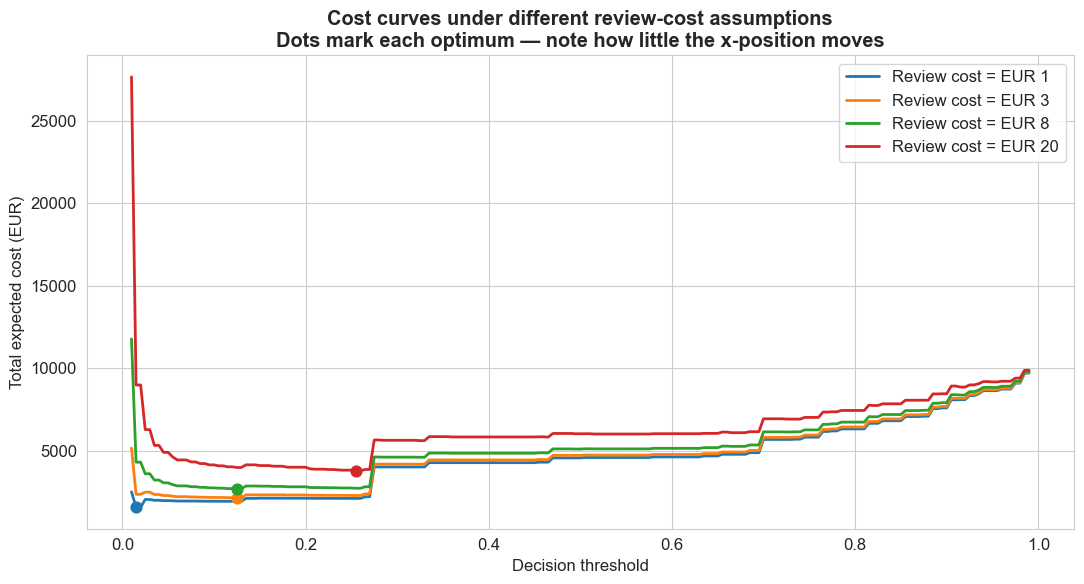

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))
for rc in [1, 3, 8, 20]:
    curve = [cost_breakdown(rf_proba, y_test_arr, amt_test_arr, t, review_cost=rc)['total_cost']
             for t in thresholds]
    ax.plot(thresholds, curve, linewidth=2, label=f'Review cost = EUR {rc}')
    ax.scatter([thresholds[int(np.argmin(curve))]], [min(curve)], s=60, zorder=5)

ax.set_xlabel('Decision threshold'); ax.set_ylabel('Total expected cost (EUR)')
ax.set_title('Cost curves under different review-cost assumptions\n'
             'Dots mark each optimum — note how little the x-position moves',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plots/cost_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8: The alert budget — reframing for how teams actually work

A fraud team does not have a threshold. It has **capacity**: some number of
transactions it can review per day. The operational question is therefore not
*"what threshold?"* but:

> *Given we can review N transactions, which N should they be, and what share of
> fraud do we catch?*

Rank every transaction by fraud probability, take the top N, and measure. This is
precision@k, and it converts the model output into a staffing conversation.

In [11]:
order = np.argsort(-rf_proba)                  # highest probability first
y_sorted   = y_test_arr[order]
amt_sorted = amt_test_arr[order]

cum_caught = np.cumsum(y_sorted)
cum_value  = np.cumsum(np.where(y_sorted == 1, amt_sorted, 0))
total_frauds = int(y_test_arr.sum())
total_value  = float(amt_test_arr[y_test_arr == 1].sum())

budget_rows = []
for k in [25, 50, 100, 150, 200, 300, 500, 1000]:
    if k > len(y_sorted):
        continue
    budget_rows.append({
        'review_budget':    k,
        'frauds_caught':    int(cum_caught[k-1]),
        'pct_frauds':       round(cum_caught[k-1] / total_frauds * 100, 1),
        'precision_at_k':   round(cum_caught[k-1] / k, 3),
        'value_recovered':  round(float(cum_value[k-1]), 2),
        'pct_value':        round(cum_value[k-1] / total_value * 100, 1),
    })

budget = pd.DataFrame(budget_rows)
print(f'Alert budget analysis — holdout of {len(y_test_arr):,} transactions, '
      f'{total_frauds} frauds worth EUR {total_value:,.2f}')
print('=' * 100)
print(budget.to_string(index=False))

k80 = int(np.argmax(cum_caught >= 0.8 * total_frauds)) + 1
print()
print(f'To catch 80% of fraud you must review {k80} transactions '
      f'({k80/len(y_sorted)*100:.2f}% of all traffic).')

Alert budget analysis — holdout of 56,962 transactions, 98 frauds worth EUR 10,644.93
 review_budget  frauds_caught  pct_frauds  precision_at_k  value_recovered  pct_value
            25             24       24.50            0.96         1,931.82      18.10
            50             49       50.00            0.98         3,600.34      33.80
           100             83       84.70            0.83         8,623.16      81.00
           150             88       89.80            0.59         8,822.22      82.90
           200             88       89.80            0.44         8,822.22      82.90
           300             89       90.80            0.30         9,457.32      88.80
           500             89       90.80            0.18         9,457.32      88.80
          1000             89       90.80            0.09         9,457.32      88.80

To catch 80% of fraud you must review 84 transactions (0.15% of all traffic).


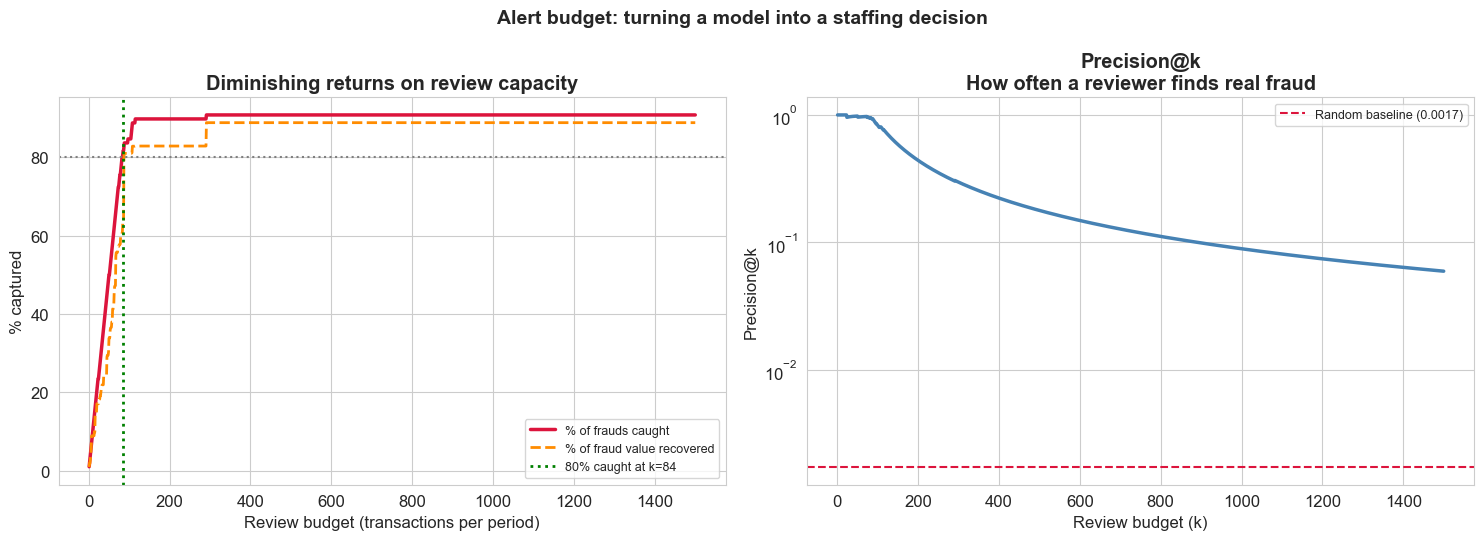

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
k_axis = np.arange(1, 1501)

ax = axes[0]
ax.plot(k_axis, cum_caught[:1500] / total_frauds * 100, color='crimson', linewidth=2.5,
        label='% of frauds caught')
ax.plot(k_axis, cum_value[:1500] / total_value * 100, color='darkorange', linewidth=2,
        ls='--', label='% of fraud value recovered')
ax.axhline(80, color='grey', ls=':', lw=1.5)
ax.axvline(k80, color='green', ls=':', lw=2, label=f'80% caught at k={k80}')
ax.set_xlabel('Review budget (transactions per period)')
ax.set_ylabel('% captured')
ax.set_title('Diminishing returns on review capacity', fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
prec_at_k = cum_caught[:1500] / k_axis
ax.plot(k_axis, prec_at_k, color='steelblue', linewidth=2.5)
ax.axhline(y_test_arr.mean(), color='crimson', ls='--', lw=1.5,
           label=f'Random baseline ({y_test_arr.mean():.4f})')
ax.set_xlabel('Review budget (k)'); ax.set_ylabel('Precision@k')
ax.set_yscale('log')
ax.set_title('Precision@k\nHow often a reviewer finds real fraud', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Alert budget: turning a model into a staffing decision', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/alert_budget.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Persist the results

In [13]:
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv(override=True)
engine = create_engine(
    f"postgresql://{os.getenv('DB_USER','postgres')}:{os.getenv('DB_PASS')}"
    f"@{os.getenv('DB_HOST','localhost')}:{os.getenv('DB_PORT','5432')}/{os.getenv('DB_NAME','fraud_detection')}"
)

costs.to_sql('cost_curve', engine, if_exists='replace', index=False)
budget.to_sql('alert_budget', engine, if_exists='replace', index=False)
sens_df.to_sql('cost_sensitivity', engine, if_exists='replace', index=False)

print('Written to PostgreSQL: cost_curve, alert_budget, cost_sensitivity')

Written to PostgreSQL: cost_curve, alert_budget, cost_sensitivity


---

## Summary

**What changed.** The threshold is no longer chosen by F1. It is chosen by minimising
expected cost in euros, with each false negative weighted by the actual value of the
transaction that was missed.

**Why it matters.** F1 assumes a missed fraud and a false alarm are equally bad. In this
dataset the true asymmetry is roughly 41:1. Optimising the wrong objective produces the
wrong operating point, and the gap is measurable in money.

**The assumption we stated rather than hid.** Review cost is assumed at €3. Step 7 shows
how far the optimal threshold moves across a 20× range of that assumption — if it barely
moves, the conclusion holds regardless.

**The reframe that matters operationally.** Fraud teams have review capacity, not
thresholds. Precision@k answers the question they actually ask, and turns a model
output into a staffing decision.

### Limitations worth stating out loud

- Review cost is assumed, not measured
- The cost model ignores second-order effects: customer churn from a false decline,
  chargeback fees, regulatory exposure, reputational damage
- It assumes a reviewed fraud is always successfully stopped — recovery is never 100%
- Fraud values here are dataset-specific and will not generalise
- Still evaluated on a random split; `05-temporal-validation.ipynb` addresses the
  lookahead leakage that implies